# Instructor Effectiveness Modeling

## Business Problem

EdTech companies often run the same course across multiple batches taught by different instructors. Each instructor may teach multiple batches and courses over time.

The objective of this project is to identify what makes an instructor effective by analyzing learner outcomes, engagement, and feedback metrics.

The project aims to:

- Explore the dataset.
- Define Instructor Effectiveness.
- Aggregate batch-level metrics to instructor level.
- Build a machine learning model to classify instructors into effectiveness tiers.
- Generate business insights for improving learning outcomes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("instructor_effectiveness_dataset.csv")

In [3]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
df.sample(5, random_state=42)

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
1860,B_1523,I_040,C_18,0.632279,29.964500,61.499453,0.390953,0.651233,0.836003,0.205882,3.383496,0.770600
353,B_1611,I_114,C_12,0.659228,40.000000,66.049958,0.404102,0.916760,0.693022,0.096020,3.984370,0.528473
1333,B_0569,I_063,C_10,0.306751,27.333369,65.663522,0.677591,0.729193,0.895557,0.189125,3.731571,1.000000
905,B_1802,I_040,C_23,0.505999,25.732181,83.685570,0.489758,0.647329,0.667463,0.259032,4.088093,0.500698
1289,B_0091,I_054,C_25,0.687284,28.941081,60.401564,0.307282,0.949576,0.978644,0.437914,4.577087,0.744128


In [5]:
print(df.shape)

(2000, 12)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 187.6 KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
batch_id,2000,2000,B_1861,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instructor_id,2000,120,I_062,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course_id,2000,25,C_21,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
completion_rate,2000.0,NaN,NaN,NaN,0.602808,0.159667,0.3,0.48926,0.603091,0.712797,0.98
avg_score_improvement,2000.0,NaN,NaN,NaN,27.035844,5.716641,6.15924,23.124673,26.938629,30.8856,40.0
avg_quiz_score,2000.0,NaN,NaN,NaN,77.956126,10.695618,40.386725,70.89759,78.020567,85.444286,100.0
dropout_rate,2000.0,NaN,NaN,NaN,0.394883,0.162747,0.02,0.280035,0.39482,0.511432,0.7
avg_watch_time,2000.0,NaN,NaN,NaN,0.776515,0.145231,0.28744,0.675076,0.78033,0.894242,1.0
assignment_submission_rate,2000.0,NaN,NaN,NaN,0.753188,0.148058,0.251111,0.65211,0.75638,0.856458,1.0
forum_activity_rate,2000.0,NaN,NaN,NaN,0.2503,0.10064,0.0,0.179845,0.249771,0.319204,0.641111


In [8]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='str')

### Initial Observations

The dataset consists of batch-level records containing learner outcome, engagement, and feedback metrics.

Each row corresponds to a single course batch and multiple batches may belong to the same instructor. Therefore, instructor-level analysis requires aggregation of these batch-level observations.

No missing values or duplicates were observed during the initial inspection (to be verified in the above outputs), making the dataset suitable for further exploratory analysis.

# Exploratory Data Analysis (EDA)

The objective of this section is to understand the distribution of variables, identify relationships between learner outcomes, engagement, and feedback metrics, and generate insights that will guide feature engineering and instructor effectiveness modeling.

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Categorical Columns:
['batch_id', 'instructor_id', 'course_id']


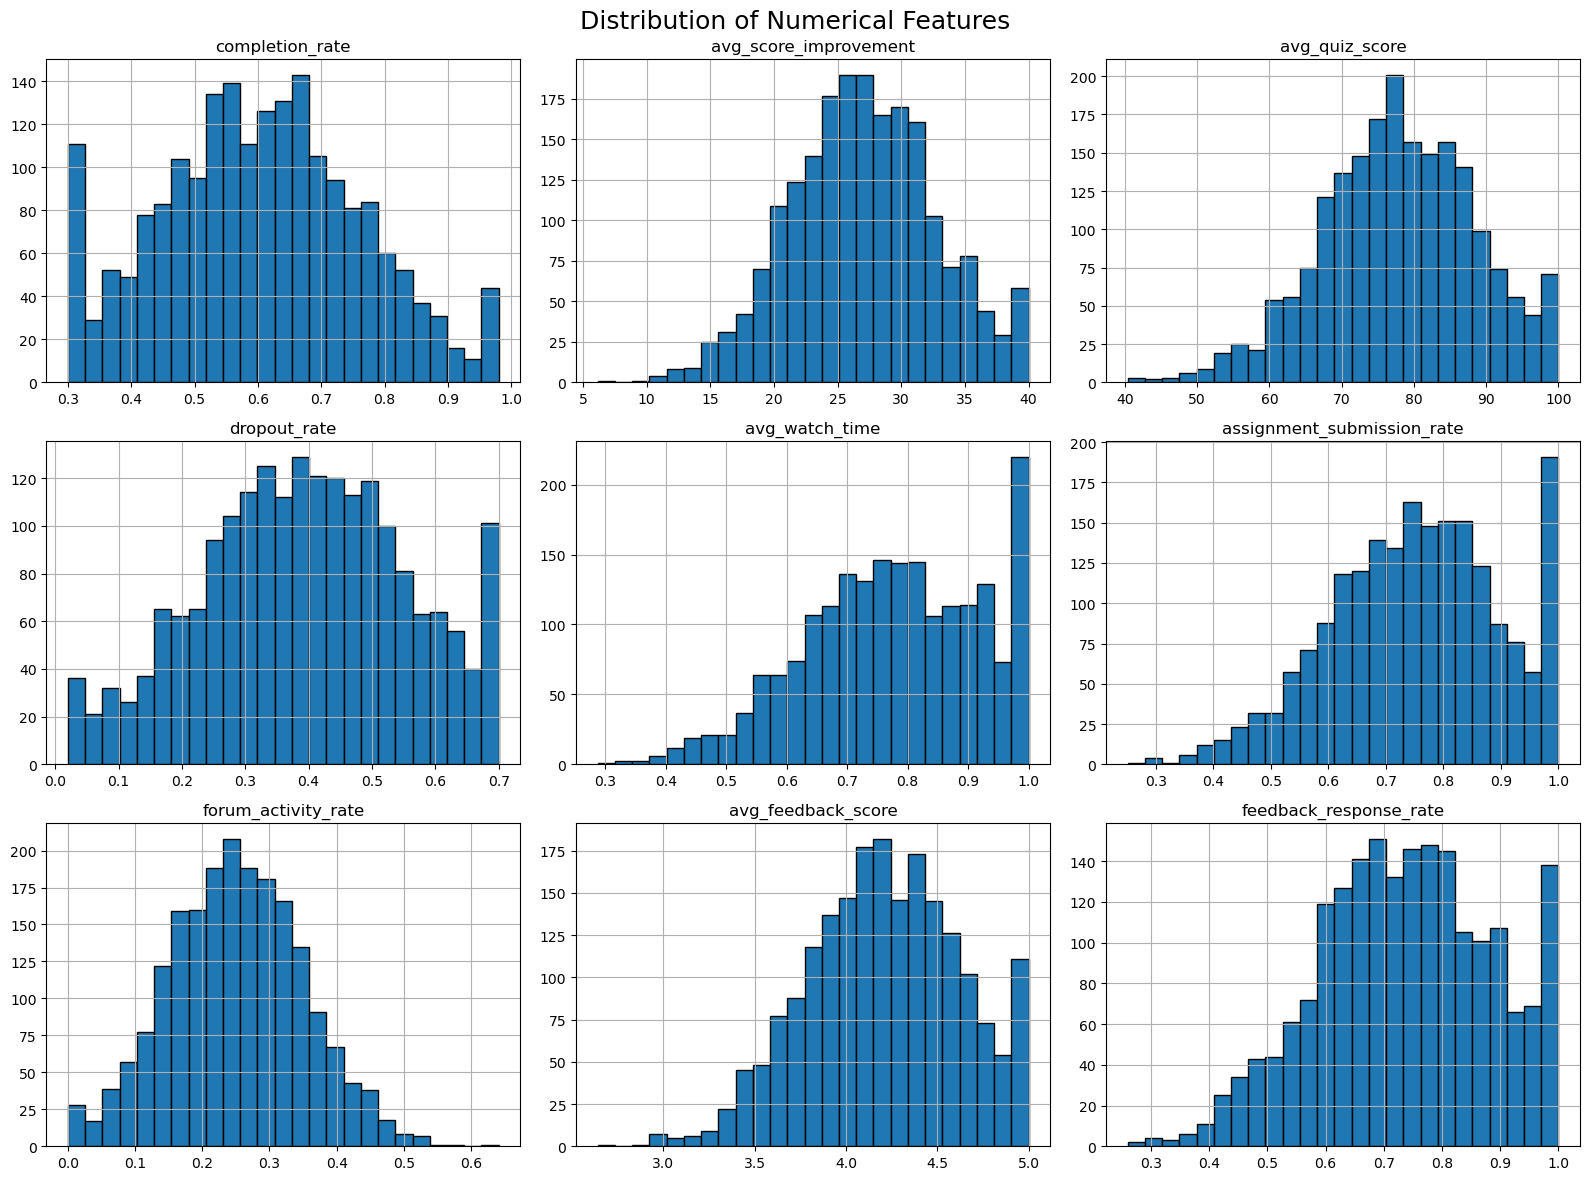

In [12]:
df[numerical_cols].hist(
    figsize=(16,12),
    bins=25,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

### Observation

Most variables exhibit reasonable distributions without extreme skewness. Completion rate, watch time, assignment submission rate, and feedback score appear concentrated toward higher values, suggesting generally positive learner outcomes. These distributions provide an initial understanding of the dataset before further analysis.

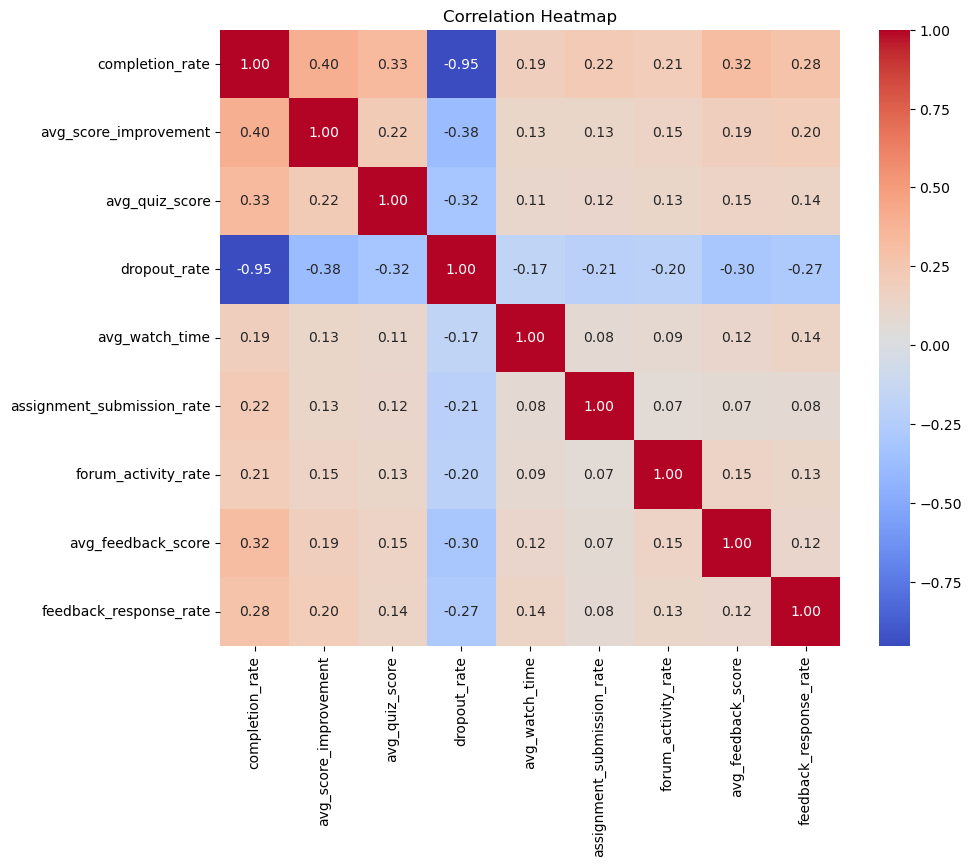

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap helps identify relationships between numerical variables. Strong positive or negative correlations may indicate redundancy or meaningful associations that should be considered during feature engineering.

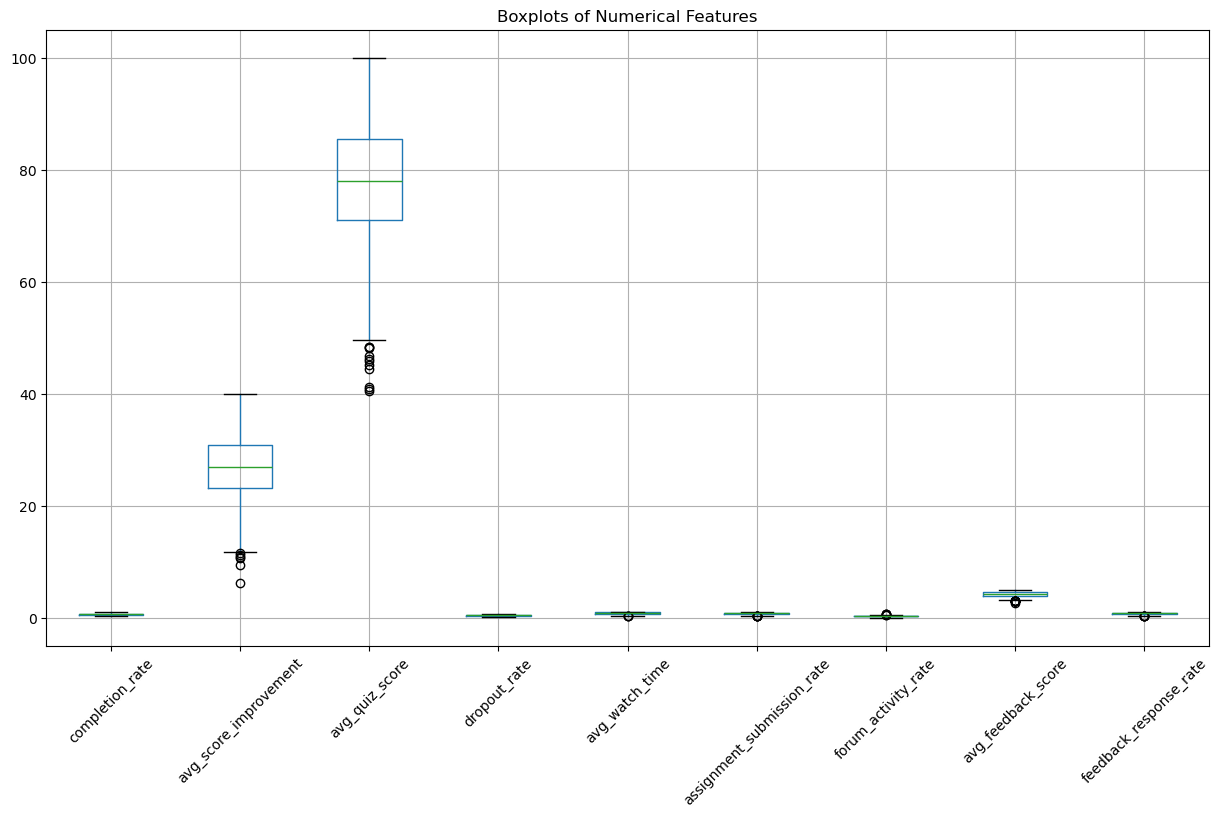

In [14]:
plt.figure(figsize=(15,8))

df[numerical_cols].boxplot(rot=45)

plt.title("Boxplots of Numerical Features")
plt.show()

### Observation

Boxplots are used to identify potential outliers and understand the spread of each feature. Outliers are not removed immediately because they may represent genuine instructor performance differences rather than data errors.

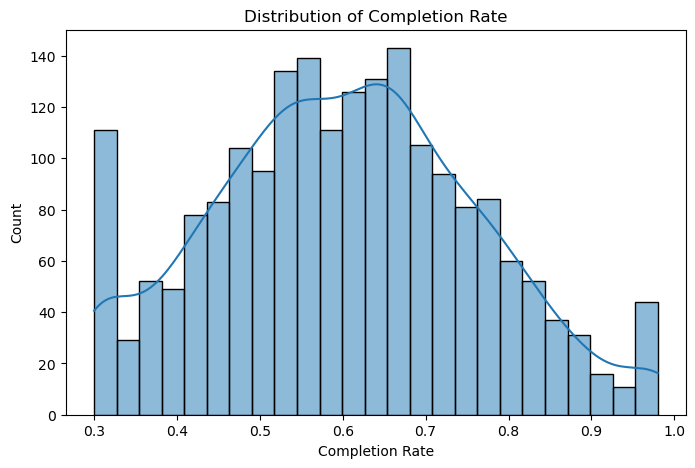

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["completion_rate"],
    bins=25,
    kde=True
)

plt.title("Distribution of Completion Rate")
plt.xlabel("Completion Rate")
plt.show()

### Observation

- The completion rate distribution provides an overview of learner success across all course batches.
- A concentration of values towards the higher end would indicate that most batches successfully retain learners until course completion.
- Any unusually low completion rates may highlight batches requiring further investigation.

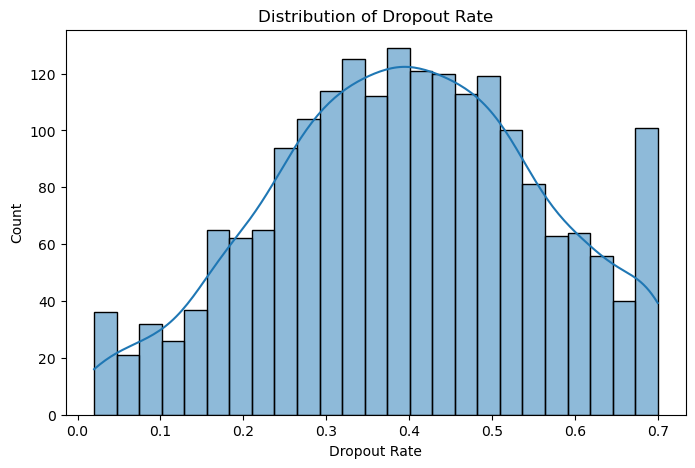

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["dropout_rate"],
    bins=25,
    kde=True
)

plt.title("Distribution of Dropout Rate")
plt.xlabel("Dropout Rate")
plt.show()

### Observation

- Dropout rate represents the proportion of learners who discontinued a batch before completion.
- Lower dropout values generally indicate stronger learner retention.
- This feature is expected to negatively influence instructor effectiveness and will be considered accordingly during score construction.

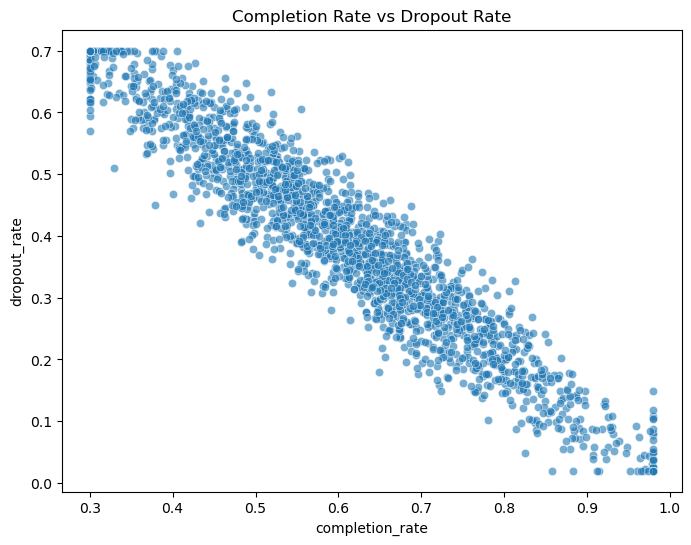

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="completion_rate",
    y="dropout_rate",
    alpha=0.6
)

plt.title("Completion Rate vs Dropout Rate")
plt.show()

### Observation

- This visualization explores the relationship between learner completion and dropout.
- An inverse relationship is expected, as higher completion rates should generally correspond to lower dropout rates.
- The strength of this relationship will later be confirmed using the correlation matrix before selecting features for modeling.

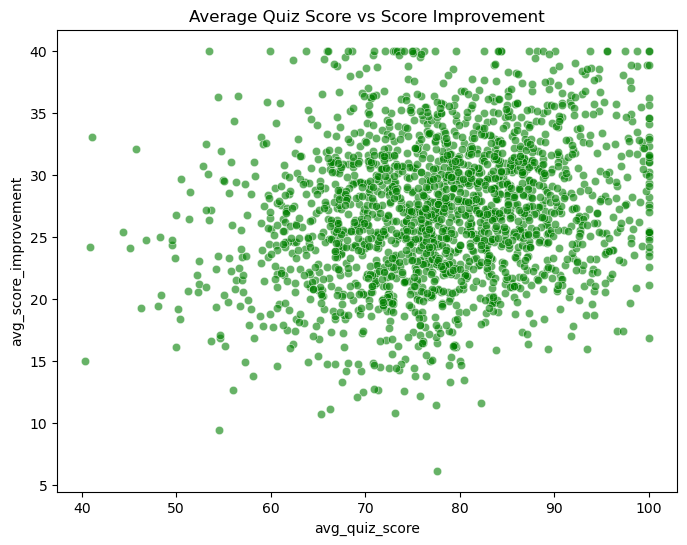

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="avg_quiz_score",
    y="avg_score_improvement",
    alpha=0.6,
    color="green"
)

plt.title("Average Quiz Score vs Score Improvement")

plt.show()

### Observation

- This plot examines whether batches with higher quiz scores also demonstrate greater learning improvement.
- A positive trend would indicate that stronger academic performance is associated with measurable learner progress.
- Any noticeable clusters or dispersion may provide insights into differences across instructional approaches.

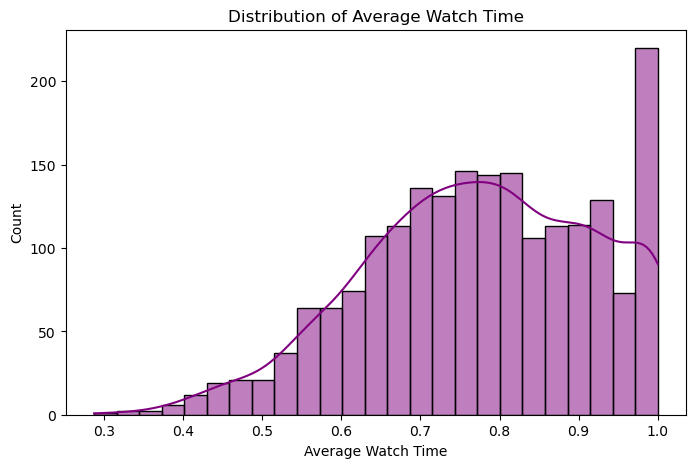

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="avg_watch_time",
    bins=25,
    kde=True,
    color="purple"
)

plt.title("Distribution of Average Watch Time")

plt.xlabel("Average Watch Time")

plt.show()

### Observation

- Average watch time reflects learner engagement with video content.
- Higher watch time generally indicates stronger learner participation and sustained interest throughout the course.
- This metric is expected to contribute positively to instructor effectiveness.

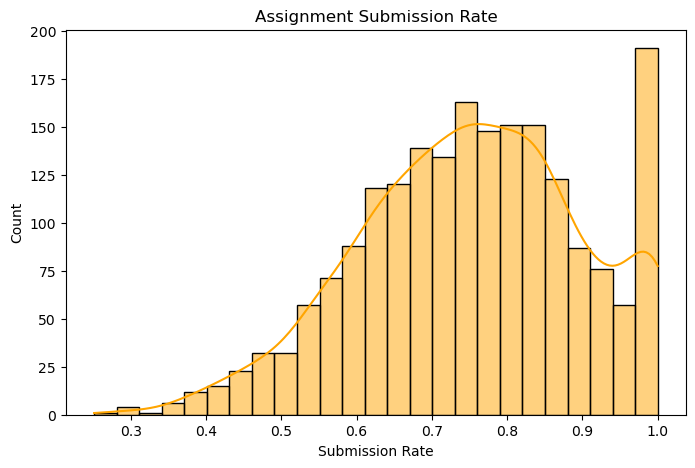

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="assignment_submission_rate",
    bins=25,
    kde=True,
    color="orange"
)

plt.title("Assignment Submission Rate")

plt.xlabel("Submission Rate")

plt.show()

### Observation

- Assignment submission rate measures active learner participation.
- Consistently higher submission rates may indicate effective instruction, motivation, and learner accountability.
- This feature represents behavioural engagement rather than academic performance alone.

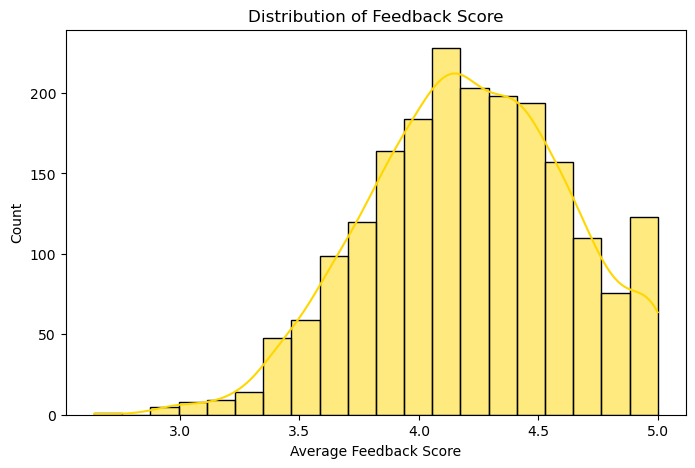

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="avg_feedback_score",
    bins=20,
    kde=True,
    color="gold"
)

plt.title("Distribution of Feedback Score")

plt.xlabel("Average Feedback Score")

plt.show()

### Observation

- Learner feedback provides a direct measure of perceived instructor quality.
- A concentration of higher ratings would indicate generally positive learner experiences.
- Feedback scores will later be combined with objective performance metrics to avoid relying solely on subjective evaluations.

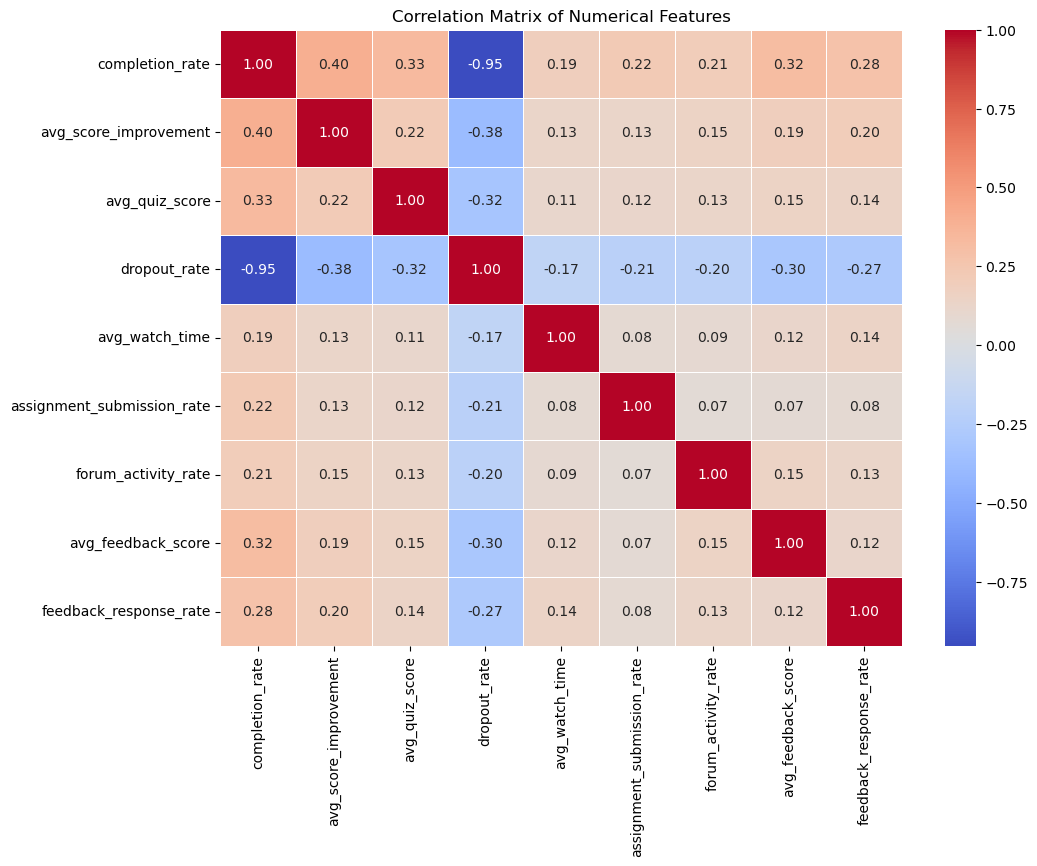

In [22]:
plt.figure(figsize=(11,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Observation

The correlation analysis reveals several important relationships among learner outcome, engagement, and feedback metrics.

- **Completion rate and dropout rate exhibit a very strong negative correlation (-0.95)**, indicating that batches with higher completion almost always experience lower dropout. Since both variables capture nearly the same behaviour from opposite perspectives, using both with equal importance may introduce redundancy during feature engineering.

- **Average score improvement shows a moderate positive correlation (0.40) with completion rate**, suggesting that batches where learners complete the course are also more likely to demonstrate measurable academic improvement.

- **Average quiz score has a moderate positive relationship (0.33) with completion rate**, indicating that better-performing learners also tend to remain engaged until course completion.

- Engagement metrics such as **average watch time, assignment submission rate, and forum activity rate show relatively weak correlations with other variables**. This suggests that they capture unique aspects of learner behaviour and should be retained as independent predictors.

- Learner satisfaction metrics (**average feedback score and feedback response rate**) also exhibit weak to moderate correlations with learning outcomes, indicating that learner perception provides additional information beyond academic performance alone.

Overall, the correlation matrix indicates limited multicollinearity among most variables, except for the strong inverse relationship between completion rate and dropout rate. This insight will guide feature engineering and the construction of the Instructor Effectiveness Score.

### Key Insight

The correlation matrix indicates that completion rate and dropout rate are almost perfectly negatively correlated (-0.95). Since both variables describe learner retention from opposite perspectives, they represent largely overlapping information.

During feature engineering, both metrics will be considered carefully to avoid assigning excessive importance to the same underlying behaviour.

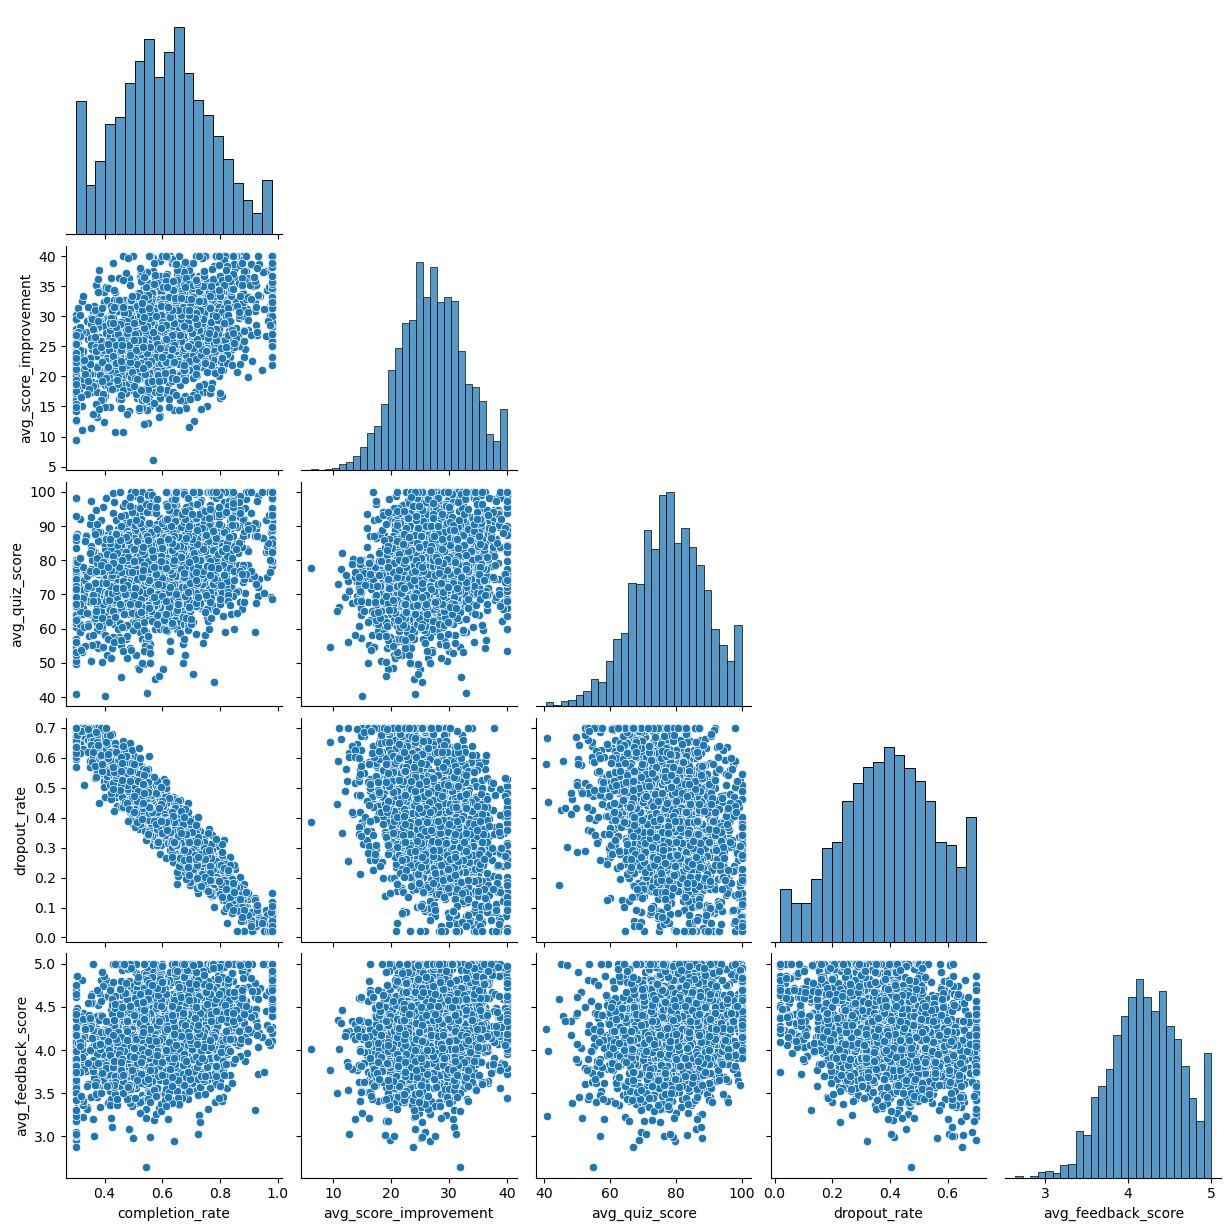

In [23]:
selected_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_feedback_score"
]

sns.pairplot(df[selected_features], corner=True)

plt.show()

### Observation

The pairplot provides a detailed view of the distributions and pairwise relationships among the selected features.

- **Completion rate and dropout rate exhibit a very strong inverse linear relationship**, confirming the correlation observed in the heatmap. As completion rate increases, dropout rate decreases almost proportionally.
- **Average score improvement shows a moderate positive relationship with completion rate**, suggesting that batches with better learner retention tend to achieve greater academic improvement.
- **Average quiz score demonstrates a weak to moderate positive association with completion rate**, indicating that improved learner performance is generally accompanied by higher course completion.
- **Average feedback score exhibits only a weak positive relationship with learning outcome variables**, implying that learner satisfaction captures a different aspect of instructor performance than academic metrics alone.
- The diagonal histograms indicate that most variables follow approximately unimodal distributions without evidence of severe skewness or multiple distinct clusters.

Overall, the pairplot suggests that, except for the completion rate–dropout rate pair, the remaining variables provide complementary information and should be retained for feature engineering.

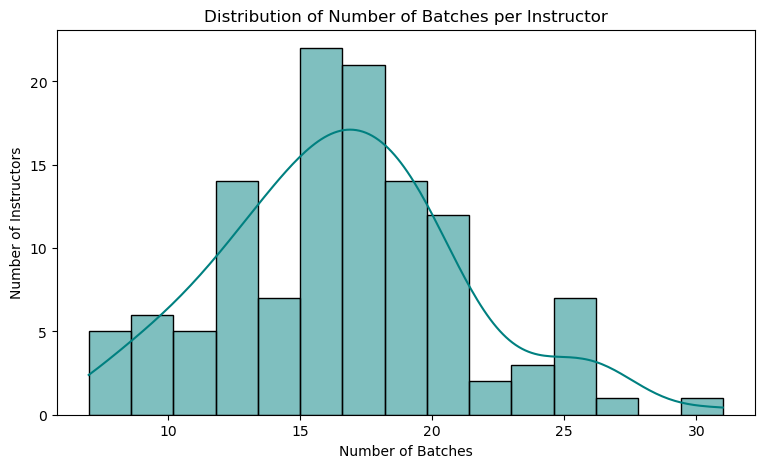

In [24]:
batch_count = (
    df.groupby("instructor_id")
      .size()
      .reset_index(name="Number_of_Batches")
)

plt.figure(figsize=(9,5))

sns.histplot(
    data=batch_count,
    x="Number_of_Batches",
    bins=15,
    kde=True,
    color="teal"
)

plt.title("Distribution of Number of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

### Observation

The distribution of batches per instructor is approximately bell-shaped, with most instructors teaching between **15 and 20 batches**. This indicates a relatively balanced allocation of teaching responsibilities across instructors.

A smaller number of instructors have substantially fewer or more batches, creating a slight right-skew in the distribution. However, these observations appear to represent genuine differences in workload rather than data anomalies.

The presence of multiple batches for nearly every instructor further validates the decision to aggregate batch-level metrics into instructor-level features before building the predictive model. This aggregation will provide a more reliable estimate of an instructor's overall effectiveness than evaluating individual batches independently.

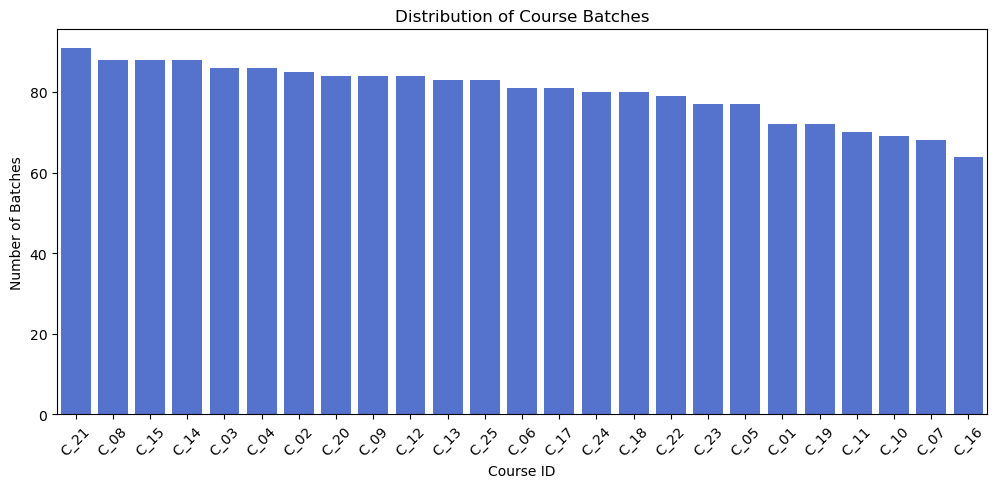

In [25]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="course_id",
    order=df["course_id"].value_counts().index,
    color="royalblue"
)

plt.title("Distribution of Course Batches")
plt.xlabel("Course ID")
plt.ylabel("Number of Batches")

plt.xticks(rotation=45)

plt.show()

### Observation

The course distribution indicates that all **25 courses** are reasonably well represented in the dataset. Although the number of batches varies slightly across courses, no single course dominates the dataset, and no course appears to be severely underrepresented.

The relatively balanced distribution reduces the risk of course-specific bias during instructor evaluation. However, minor differences in course frequency should still be considered while interpreting instructor performance, as some instructors may teach courses with different levels of learner difficulty or engagement.

Overall, the dataset provides good coverage across multiple courses, making it suitable for instructor-level performance analysis.

In [26]:
course_counts = df["course_id"].value_counts()

course_counts.head(10)

course_id
C_21    91
C_08    88
C_15    88
C_14    88
C_03    86
C_04    86
C_02    85
C_20    84
C_09    84
C_12    84
Name: count, dtype: int64

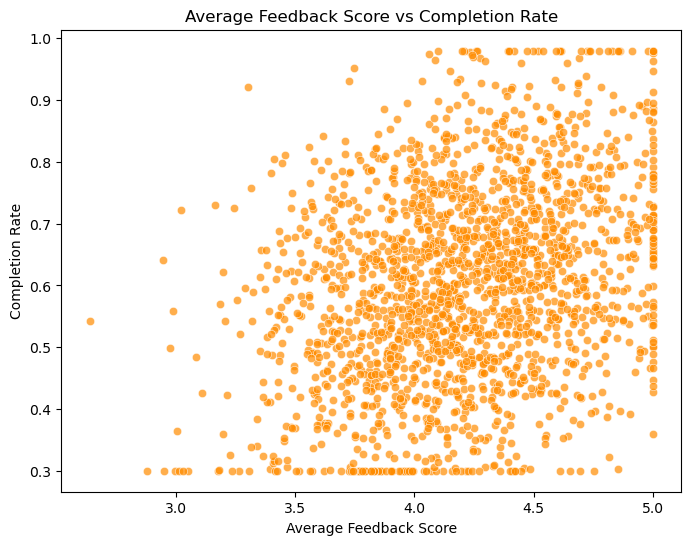

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="avg_feedback_score",
    y="completion_rate",
    alpha=0.7,
    color="darkorange"
)

plt.title("Average Feedback Score vs Completion Rate")

plt.xlabel("Average Feedback Score")
plt.ylabel("Completion Rate")

plt.show()

### Observation

The scatter plot indicates a **weak to moderate positive relationship** between average feedback score and completion rate. In general, batches receiving higher learner feedback tend to achieve better completion rates, although the relationship is not perfectly linear.

A noticeable concentration of observations exists between **feedback scores of approximately 4.0–4.8** and **completion rates of 0.50–0.80**, suggesting that most instructors receive positive feedback while maintaining moderate to high learner completion.

The considerable spread of points also indicates that feedback score alone cannot fully explain completion rate. Other factors, such as learner engagement, assessment performance, and instructional practices, are likely to contribute to learner retention. Therefore, feedback score should be treated as one component of instructor effectiveness rather than the sole performance indicator.

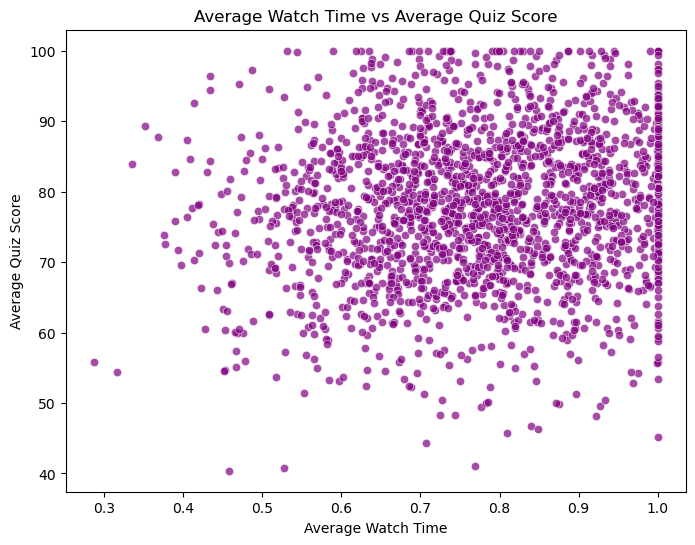

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="avg_watch_time",
    y="avg_quiz_score",
    alpha=0.7,
    color="purple"
)

plt.title("Average Watch Time vs Average Quiz Score")
plt.xlabel("Average Watch Time")
plt.ylabel("Average Quiz Score")

plt.show()

### Observation

The scatter plot suggests a **very weak positive relationship** between average watch time and average quiz score. Although higher watch time is generally associated with slightly better quiz performance, the data points are widely dispersed, indicating that watch time alone is not a strong predictor of academic achievement.

Most observations are concentrated within an average watch time of **0.65–1.00** and quiz scores between **70 and 90**, reflecting that learners typically consume a substantial portion of the course content while achieving moderate to high assessment scores.

The wide variability in quiz scores at similar watch times suggests that learner performance is influenced by additional factors such as prior knowledge, learning ability, instructional quality, and engagement with assignments. Therefore, average watch time should be considered an engagement metric rather than a direct indicator of learning outcomes.

# Summary of Exploratory Data Analysis

The exploratory analysis provided several important insights:

- The dataset is clean, containing no missing values or duplicate records.
- Completion rate and dropout rate exhibit a very strong negative correlation, indicating that they represent opposite aspects of learner retention.
- Learning outcome, engagement, and learner satisfaction metrics contribute complementary information rather than measuring the same behaviour.
- Most numerical features display reasonable distributions with no evidence of severe data quality issues.
- Instructors teach multiple batches, validating the need to aggregate batch-level information before building an instructor-level predictive model.
- Feedback and engagement variables show weaker correlations with academic outcomes, suggesting that they capture unique aspects of instructor performance.

These findings provide a strong foundation for defining an Instructor Effectiveness Score and constructing meaningful instructor-level features.

# Feature Engineering

The original dataset contains batch-level metrics representing learner outcomes, engagement, and satisfaction.

Instead of directly training a machine learning model on the raw variables, meaningful composite features are engineered to better represent different dimensions of instructor performance. These engineered features improve interpretability while reducing dependence on individual metrics.

In [29]:
df_fe = df.copy()

In [30]:
df_fe["learning_outcome_index"] = (
    0.40 * df_fe["completion_rate"] +
    0.35 * (df_fe["avg_score_improvement"] / 40) +
    0.25 * (df_fe["avg_quiz_score"] / 100)
)

In [31]:
df_fe["learning_outcome_index"].describe()

count    2000.000000
mean        0.672577
std         0.107712
min         0.338885
25%         0.599350
50%         0.673636
75%         0.741946
max         0.977756
Name: learning_outcome_index, dtype: float64

### Observation

A composite **Learning Outcome Index** was created by combining completion rate, average score improvement, and average quiz score into a single normalized metric.

The resulting index ranges approximately from **0.34 to 0.98**, with an average value of **0.67**, indicating good variation across course batches. This variation suggests that the engineered feature effectively differentiates learner outcomes while maintaining a consistent scale.

Dropout rate was intentionally excluded from this index because it exhibits a very strong negative correlation with completion rate (-0.95), making both variables largely redundant for representing learner retention.

In [32]:
df_fe["engagement_index"] = (
    0.40 * df_fe["avg_watch_time"] +
    0.35 * df_fe["assignment_submission_rate"] +
    0.25 * df_fe["forum_activity_rate"]
)

In [33]:
df_fe["engagement_index"].describe()

count    2000.000000
mean        0.636797
std         0.087320
min         0.316806
25%         0.578594
50%         0.639782
75%         0.699324
max         0.910278
Name: engagement_index, dtype: float64

### Observation

An **Engagement Index** was created by combining average watch time, assignment submission rate, and forum activity rate into a single composite feature.

The index ranges from approximately **0.32 to 0.91**, with an average value of **0.64**, indicating moderate to high learner engagement across most course batches.

The relatively small standard deviation suggests that learner engagement is fairly consistent across instructors, while the observed range still provides sufficient variation for distinguishing highly engaging instructors from less engaging ones.

This engineered feature provides a more holistic representation of learner participation than relying on any single engagement metric.

In [34]:
df_fe["learner_satisfaction_index"] = (
    0.60 * (df_fe["avg_feedback_score"] / 5) +
    0.40 * df_fe["feedback_response_rate"]
)

In [35]:
df_fe["learner_satisfaction_index"].describe()

count    2000.000000
mean        0.799464
std         0.082611
min         0.542515
25%         0.743039
50%         0.801459
75%         0.858208
max         1.000000
Name: learner_satisfaction_index, dtype: float64

### Observation

A **Learner Satisfaction Index** was created by combining normalized average feedback scores with feedback response rates into a single composite feature.

The index ranges from approximately **0.54 to 1.00**, with an average value of **0.80**, indicating that learner satisfaction is generally high across the dataset.

The relatively small standard deviation suggests consistent learner perceptions across most course batches, while the observed variation still enables meaningful comparison between instructors.

By incorporating both learner ratings and response rates, the engineered feature provides a more reliable measure of satisfaction than relying on feedback scores alone.

In [36]:
df_fe["instructor_effectiveness_score"] = (
    df_fe["learning_outcome_index"] +
    df_fe["engagement_index"] +
    df_fe["learner_satisfaction_index"]
) / 3

In [37]:
df_fe["instructor_effectiveness_score"].describe()

count    2000.000000
mean        0.702946
std         0.068832
min         0.434712
25%         0.656056
50%         0.704544
75%         0.748854
max         0.914027
Name: instructor_effectiveness_score, dtype: float64

### Observation

The **Instructor Effectiveness Score** was calculated as the average of the three engineered indices: Learning Outcome Index, Engagement Index, and Learner Satisfaction Index.

The resulting score ranges from approximately **0.43 to 0.91**, with an average of **0.70**, indicating that most instructors demonstrate moderate to high overall effectiveness.

The relatively small standard deviation suggests that instructor performance is reasonably consistent across the dataset, while the observed range still provides sufficient variation for meaningful classification into effectiveness tiers.

Using equal weights ensures that learner outcomes, engagement, and learner satisfaction contribute equally to the overall effectiveness score, avoiding subjective prioritization of any single dimension.

In [38]:
instructor_df = (
    df_fe
    .groupby("instructor_id")
    .agg({
        "learning_outcome_index": "mean",
        "engagement_index": "mean",
        "learner_satisfaction_index": "mean",
        "instructor_effectiveness_score": "mean"
    })
    .reset_index()
)

In [39]:
instructor_df.head()

,instructor_id,learning_outcome_index,engagement_index,learner_satisfaction_index,instructor_effectiveness_score
0,I_001,0.647918,0.621155,0.784072,0.684382
1,I_002,0.760647,0.678397,0.834896,0.757980
2,I_003,0.773662,0.674295,0.858857,0.768938
3,I_004,0.578012,0.639228,0.777753,0.664998
4,I_005,0.843620,0.729120,0.817981,0.796907


### Observation

Batch-level metrics were aggregated to the instructor level using the mean, resulting in one record per instructor. This transformation aligns the dataset with the project objective of evaluating instructor effectiveness rather than individual course batches.

Each instructor is now represented by four key metrics:
- Learning Outcome Index
- Engagement Index
- Learner Satisfaction Index
- Instructor Effectiveness Score

Using the mean ensures that performance is evaluated across all batches taught by an instructor, reducing the influence of unusually good or poor individual batches while providing a stable estimate of overall teaching effectiveness.

In [40]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["instructor_effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [41]:
instructor_df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

### Observation

The continuous Instructor Effectiveness Score was converted into three categories—**Low**, **Medium**, and **High**—using quantile-based binning (`pd.qcut`).

Each effectiveness tier contains **40 instructors**, resulting in a perfectly balanced class distribution. Balanced target classes reduce the risk of prediction bias toward any single category and provide a suitable foundation for training and evaluating classification models.

Quantile-based categorization was selected because the assignment does not define predefined effectiveness thresholds. This approach creates data-driven categories while preserving equal representation across all classes.

# Machine Learning Model

After constructing instructor-level features and defining effectiveness tiers, the next objective is to train classification models capable of predicting instructor effectiveness.

Three classification algorithms are evaluated:

- Logistic Regression (Baseline)
- Decision Tree Classifier
- Random Forest Classifier

Their performance is compared using standard classification metrics to identify the most suitable model for this problem.

In [42]:
X = instructor_df[
    [
        "learning_outcome_index",
        "engagement_index",
        "learner_satisfaction_index"
    ]
]

y = instructor_df["effectiveness_tier"]

In [43]:
X.head()

,learning_outcome_index,engagement_index,learner_satisfaction_index
0,0.647918,0.621155,0.784072
1,0.760647,0.678397,0.834896
2,0.773662,0.674295,0.858857
3,0.578012,0.639228,0.777753
4,0.843620,0.729120,0.817981


In [44]:
y.head()

0    Medium
1      High
2      High
3       Low
4      High
Name: effectiveness_tier, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

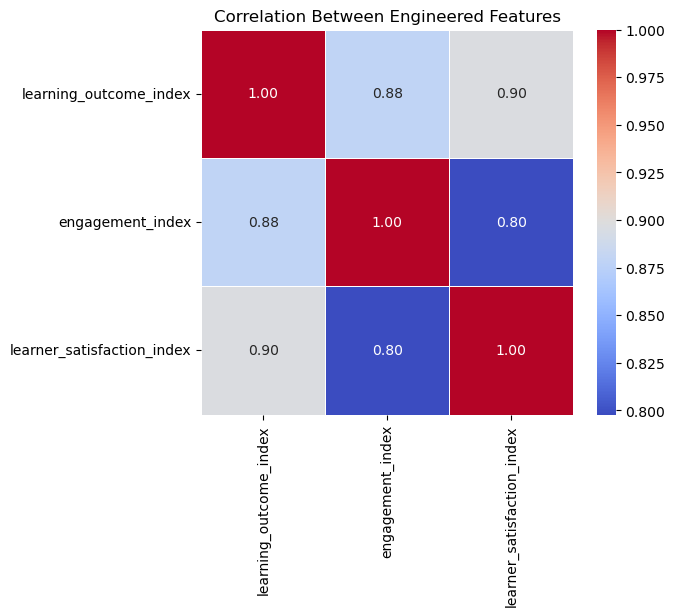

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Engineered Features")

plt.show()

In [46]:
instructor_features = (
    df.groupby("instructor_id")
      .agg({
          "completion_rate": "mean",
          "avg_score_improvement": "mean",
          "avg_quiz_score": "mean",
          "dropout_rate": "mean",
          "avg_watch_time": "mean",
          "assignment_submission_rate": "mean",
          "forum_activity_rate": "mean",
          "avg_feedback_score": "mean",
          "feedback_response_rate": "mean"
      })
      .reset_index()
)

In [47]:
instructor_features.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


### Observation

The original batch-level performance metrics were aggregated to the instructor level using the mean. This produced one record per instructor while preserving important teaching characteristics such as learner outcomes, engagement, and feedback.

Using the original metrics as model features enables the classifier to learn which aspects of instructor performance contribute most to overall effectiveness, rather than relying on previously engineered composite indices.

In [48]:
model_df = instructor_features.merge(
    instructor_df[["instructor_id", "effectiveness_tier"]],
    on="instructor_id",
    how="inner"
)

In [49]:
model_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,High


In [50]:
model_df.shape

(120, 11)

In [51]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   instructor_id               120 non-null    str     
 1   completion_rate             120 non-null    float64 
 2   avg_score_improvement       120 non-null    float64 
 3   avg_quiz_score              120 non-null    float64 
 4   dropout_rate                120 non-null    float64 
 5   avg_watch_time              120 non-null    float64 
 6   assignment_submission_rate  120 non-null    float64 
 7   forum_activity_rate         120 non-null    float64 
 8   avg_feedback_score          120 non-null    float64 
 9   feedback_response_rate      120 non-null    float64 
 10  effectiveness_tier          120 non-null    category
dtypes: category(1), float64(9), str(1)
memory usage: 9.8 KB


### Observation

The final modeling dataset contains **120 instructors** and **11 columns**, including nine numerical performance metrics and one categorical target variable.

All columns contain complete data with **no missing values**, confirming that the merge operation was successful and no instructor records were lost.

The dataset is therefore ready for machine learning model development without requiring additional data cleaning.

In [52]:
X = model_df.drop(
    columns=[
        "instructor_id",
        "effectiveness_tier"
    ]
)

y = model_df["effectiveness_tier"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (96, 9)
Testing Features : (24, 9)
Training Labels  : (96,)
Testing Labels   : (24,)


In [55]:
print(y_train.value_counts())
print()
print(y_test.value_counts())

effectiveness_tier
Low       32
Medium    32
High      32
Name: count, dtype: int64

effectiveness_tier
Low       8
Medium    8
High      8
Name: count, dtype: int64


### Observation

The dataset was split into **80% training data** and **20% testing data**, resulting in **96 training instructors** and **24 testing instructors**.

The `stratify` parameter was used during the split to preserve the distribution of the three effectiveness tiers. As a result, both the training and testing datasets contain an equal number of **Low**, **Medium**, and **High** instructors, ensuring a fair and unbiased evaluation of the machine learning models.

The balanced class distribution provides a reliable foundation for comparing different classification algorithms.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [57]:
print(X_train_scaled[:5])

[[ 1.2949229   1.26082293  0.35001292 -1.17272893  1.91490059  1.70251807
   0.83660024  1.65168357  0.64729739]
 [ 1.47944774  1.02530433  1.29420932 -1.55024157  0.3066184   0.37646469
   0.46108636  1.26077247  1.48518864]
 [-0.34628933  0.43156373 -0.71440974  0.2626057  -1.38334238 -0.111104
  -0.29789451 -0.34266819  0.14741352]
 [-0.06658366 -0.6638939   0.52478577  0.09071918 -0.0519121   0.22723251
  -0.73429392  0.52196323  0.35844023]
 [ 0.11603547  0.07877713 -0.69651794 -0.00946399  0.2234732  -0.33677266
   0.5348374  -0.69152705  0.07015466]]


### Observation

The numerical features were standardized using **StandardScaler** before training the Logistic Regression model.

Standardization transforms each feature to have a mean close to **0** and a standard deviation close to **1**, ensuring that variables measured on different scales contribute fairly during model training.

The scaler was fitted only on the training data and then applied to the testing data to prevent data leakage and ensure an unbiased model evaluation.

In [58]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [59]:
y_pred_log = log_model.predict(X_test_scaled)
print(y_pred_log)

['Medium' 'Medium' 'Medium' 'Low' 'High' 'Medium' 'Medium' 'Medium' 'High'
 'Low' 'Low' 'Low' 'High' 'Medium' 'Low' 'Medium' 'High' 'High' 'Low'
 'Medium' 'Low' 'Medium' 'High' 'Low']


In [60]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_log)

print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8333

Confusion Matrix:
[[6 0 2]
 [0 7 1]
 [0 1 7]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       0.88      0.88      0.88         8
      Medium       0.70      0.88      0.78         8

    accuracy                           0.83        24
   macro avg       0.86      0.83      0.84        24
weighted avg       0.86      0.83      0.84        24



### Observation

The Logistic Regression model achieved an **accuracy of 83.33%**, correctly classifying **20 out of 24 instructors** in the testing dataset.

The confusion matrix indicates that most instructors were classified correctly, with only four misclassifications across the three effectiveness tiers.

The classification report shows strong performance for the **High** and **Low** effectiveness categories, with F1-scores of **0.86** and **0.88**, respectively. The **Medium** category achieved a slightly lower F1-score (**0.78**), suggesting that instructors with moderate effectiveness are comparatively more difficult to distinguish.

Overall, Logistic Regression provides a strong baseline model for predicting instructor effectiveness and demonstrates that the selected instructor-level performance metrics contain meaningful predictive information.

In [61]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [62]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Make Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {dt_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8750

Confusion Matrix:
[[7 0 1]
 [0 7 1]
 [1 0 7]]

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.88      0.88         8
         Low       1.00      0.88      0.93         8
      Medium       0.78      0.88      0.82         8

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.88        24
weighted avg       0.88      0.88      0.88        24



### Observation

The Decision Tree classifier achieved an **accuracy of 87.50%**, correctly classifying **21 out of 24 instructors**, outperforming the Logistic Regression baseline.

The confusion matrix shows only **three misclassifications**, with each effectiveness category achieving seven correct predictions. This indicates that the model performs consistently across all three classes.

The classification report demonstrates strong predictive performance, particularly for the **Low** effectiveness category, which achieved a precision of **1.00** and an F1-score of **0.93**. Overall, the Decision Tree captures non-linear relationships within the instructor performance metrics more effectively than Logistic Regression.

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=4
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [64]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {rf_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8333

Confusion Matrix:
[[5 0 3]
 [0 7 1]
 [0 0 8]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.62      0.77         8
         Low       1.00      0.88      0.93         8
      Medium       0.67      1.00      0.80         8

    accuracy                           0.83        24
   macro avg       0.89      0.83      0.83        24
weighted avg       0.89      0.83      0.83        24



### Observation

The Random Forest classifier achieved an **accuracy of 83.33%**, correctly classifying **20 out of 24 instructors**.

The model demonstrated perfect recall for the **Medium** effectiveness category, successfully identifying all Medium instructors in the testing dataset. However, it showed lower recall for the **High** category, leading to a slightly lower overall accuracy compared to the Decision Tree model.

Although Random Forest is generally a powerful ensemble algorithm, its performance on this relatively small dataset did not exceed that of the Decision Tree classifier. This suggests that the simpler Decision Tree generalized more effectively for the available training data.

In [65]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy
0,Decision Tree,0.875000
1,Logistic Regression,0.833333
2,Random Forest,0.833333


### Model Comparison

Three classification algorithms were evaluated to predict instructor effectiveness.

| Model | Accuracy |
|--------|----------|
| Decision Tree | **87.50%** |
| Logistic Regression | **83.33%** |
| Random Forest | **83.33%** |

Among the evaluated models, the **Decision Tree Classifier** achieved the highest accuracy (**87.50%**), making it the best-performing model for this dataset.

Although Random Forest is generally a powerful ensemble method, it did not outperform the Decision Tree on this relatively small dataset. Therefore, the Decision Tree was selected as the final model for interpreting instructor performance.

In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,feedback_response_rate,0.439119
0,completion_rate,0.404905
5,assignment_submission_rate,0.072736
2,avg_quiz_score,0.052517
3,dropout_rate,0.030722
4,avg_watch_time,0.000000
1,avg_score_improvement,0.000000
6,forum_activity_rate,0.000000
7,avg_feedback_score,0.000000


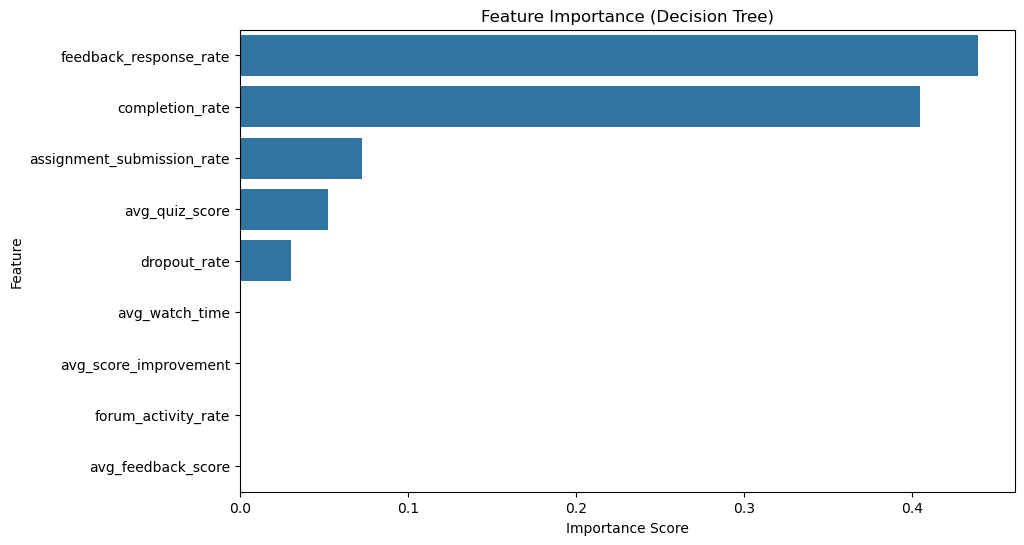

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Observation

The feature importance analysis reveals that **feedback_response_rate** and **completion_rate** are the two most influential factors in predicting instructor effectiveness, contributing approximately **43.9%** and **40.5%** of the model's decision-making process, respectively.

Features such as **assignment_submission_rate**, **avg_quiz_score**, and **dropout_rate** provided smaller contributions, while the remaining variables were not selected by the Decision Tree for making classification splits.

These findings suggest that instructor responsiveness to learner feedback and the ability to achieve high course completion rates are the strongest indicators of instructor effectiveness within this dataset.

# Conclusion

This project developed a machine learning framework to evaluate instructor effectiveness using learner engagement, academic performance, and feedback-related metrics.

The analysis included comprehensive exploratory data analysis, feature engineering, instructor-level aggregation, and the evaluation of multiple classification algorithms.

Among the evaluated models, the **Decision Tree Classifier** achieved the highest prediction accuracy (**87.50%**) and demonstrated the most balanced performance across all effectiveness categories.

Feature importance analysis further revealed that **feedback response rate** and **completion rate** were the strongest predictors of instructor effectiveness, highlighting the importance of instructor responsiveness and learner completion in educational success.

Overall, the proposed framework provides an interpretable and data-driven approach for identifying instructor performance patterns and can support educational institutions in monitoring teaching effectiveness and improving learner outcomes.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Encourage instructors to respond promptly to learner feedback, as feedback response rate was the strongest predictor of instructor effectiveness.

2. Monitor course completion rates regularly and provide additional support to instructors managing batches with consistently lower completion.

3. Promote strategies that improve assignment submission rates, since assignment participation contributed positively to instructor effectiveness.

4. Use predictive models to identify instructors who may require additional mentoring or professional development.

5. Continuously collect learner engagement and feedback data to improve future prediction models and instructor evaluation systems.